# Byte-Pair Encoding (BPE) Tokenizer

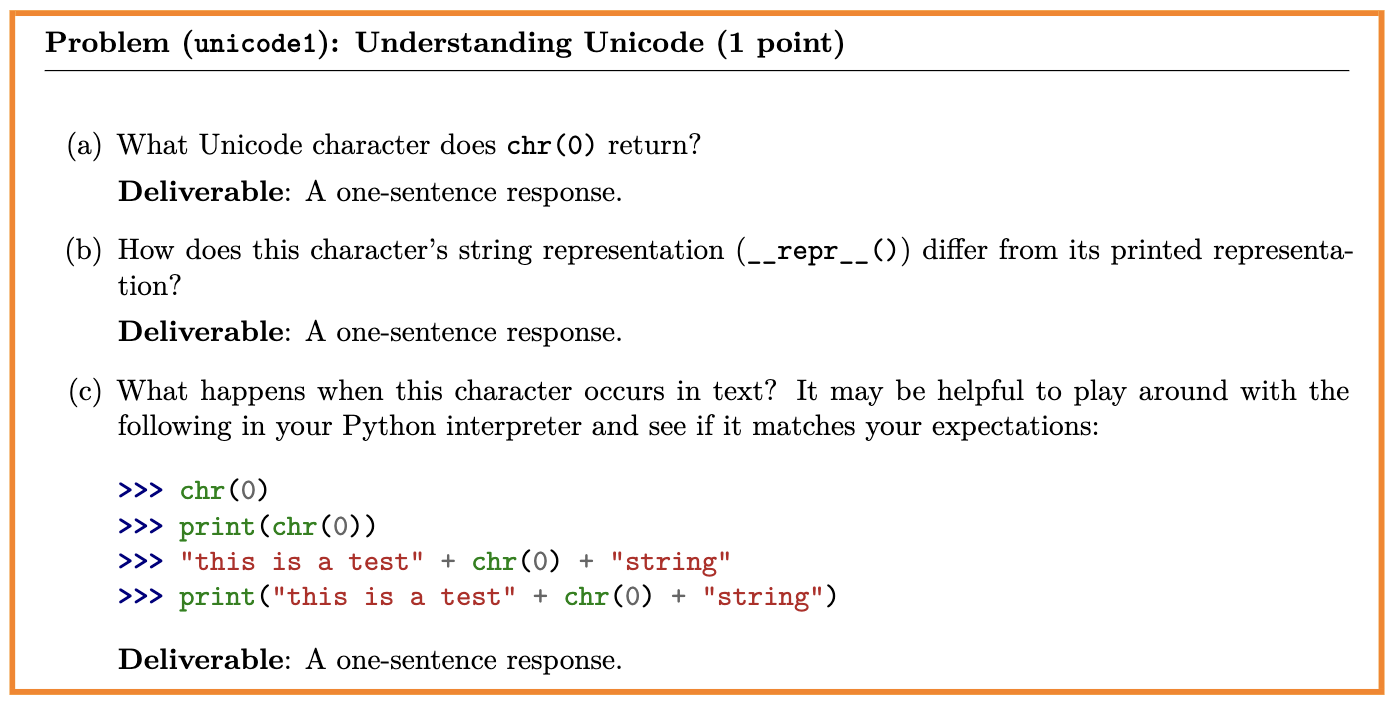

In [1]:
print(chr(0))
print(str.__repr__(chr(0)))
print("this is a test" + chr(0) + "string")

 
'\x00'
this is a test string


- (a) `char(0)` returns a `NULL`.
- (b) `str.__repr__(char(0))` returns the hexadecimal byte representation of the character, which is `'\x00'`.
- (c) `char(0)` will not display anything in the output.

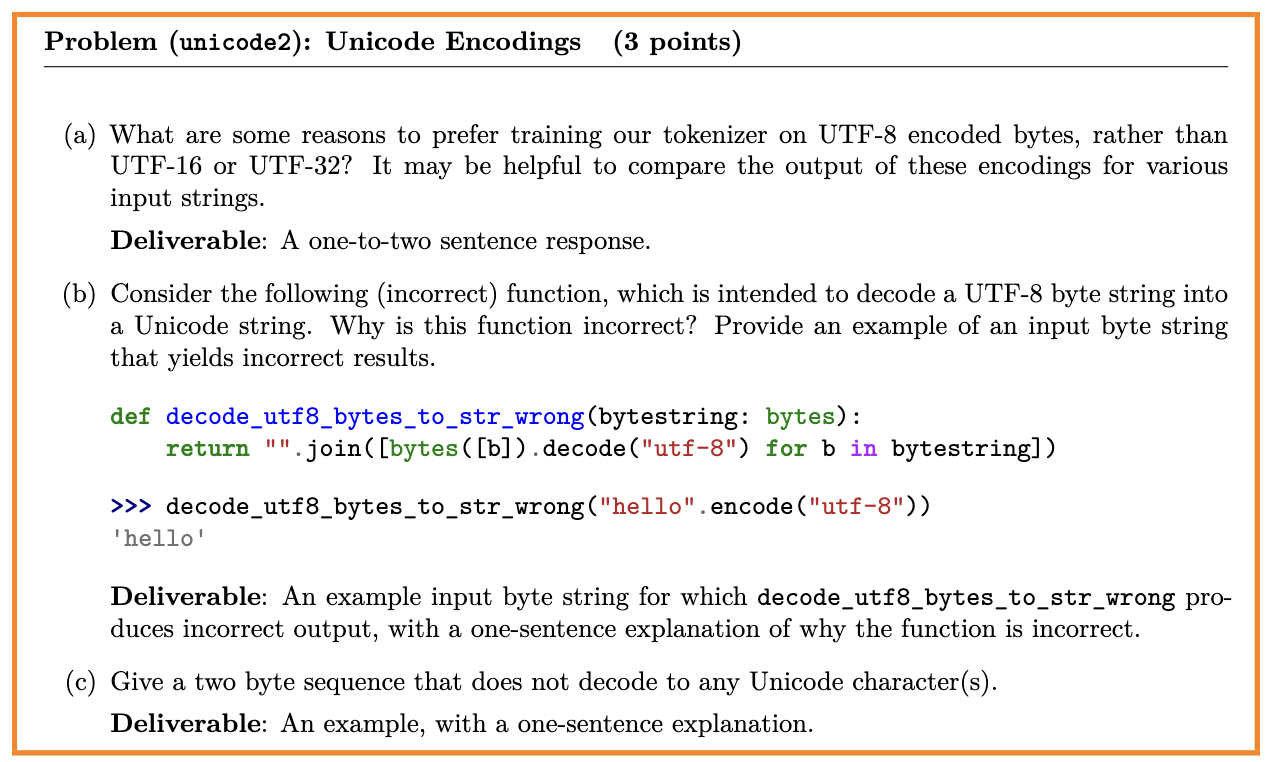

In [2]:
test_string = "hello! こんにちは!"
utf8_encoded = test_string.encode('utf-8')
utf16_encoded = test_string.encode('utf-16')
utf32_encoded = test_string.encode('utf-32')
print(utf8_encoded)
print(utf16_encoded)
print(utf32_encoded)
print(list(utf8_encoded))
print(len(list(utf8_encoded)))
print(list(utf16_encoded))
print(len(list(utf16_encoded)))
print(list(utf32_encoded))
print(len(list(utf32_encoded)))

def decode_utf8_bytes_to_str_wrong(bytestring: bytes):
    return "".join([bytes([b]).decode('utf-8') for b in bytestring])

# print(decode_utf8_bytes_to_str_wrong(utf8_encoded))

# print(b'\xc0\x80'.decode('utf-8'))
print(b'\xc2\x80'.decode('utf-8'))

b'hello! \xe3\x81\x93\xe3\x82\x93\xe3\x81\xab\xe3\x81\xa1\xe3\x81\xaf!'
b'\xff\xfeh\x00e\x00l\x00l\x00o\x00!\x00 \x00S0\x930k0a0o0!\x00'
b'\xff\xfe\x00\x00h\x00\x00\x00e\x00\x00\x00l\x00\x00\x00l\x00\x00\x00o\x00\x00\x00!\x00\x00\x00 \x00\x00\x00S0\x00\x00\x930\x00\x00k0\x00\x00a0\x00\x00o0\x00\x00!\x00\x00\x00'
[104, 101, 108, 108, 111, 33, 32, 227, 129, 147, 227, 130, 147, 227, 129, 171, 227, 129, 161, 227, 129, 175, 33]
23
[255, 254, 104, 0, 101, 0, 108, 0, 108, 0, 111, 0, 33, 0, 32, 0, 83, 48, 147, 48, 107, 48, 97, 48, 111, 48, 33, 0]
28
[255, 254, 0, 0, 104, 0, 0, 0, 101, 0, 0, 0, 108, 0, 0, 0, 108, 0, 0, 0, 111, 0, 0, 0, 33, 0, 0, 0, 32, 0, 0, 0, 83, 48, 0, 0, 147, 48, 0, 0, 107, 48, 0, 0, 97, 48, 0, 0, 111, 48, 0, 0, 33, 0, 0, 0]
56



- (a) Using UTF-8 encoding, for the same string, the byte sequence will be shorter than UTF-16 and UTF-32, which will save more storage space. What's more，UTF-8 is backward compatible with ASCII, so it can represent all ASCII characters using a single byte.
- (b) This function attempts to decode UTF-8 byte string using bytes one by one, but UTF-8 is a variable-length encoding scheme, so it may require multiple bytes to represent a single character.
- (c) `\xc0\x80`. Two byte UTF-8 encoding's scope is from U+0080 to U+07FF.

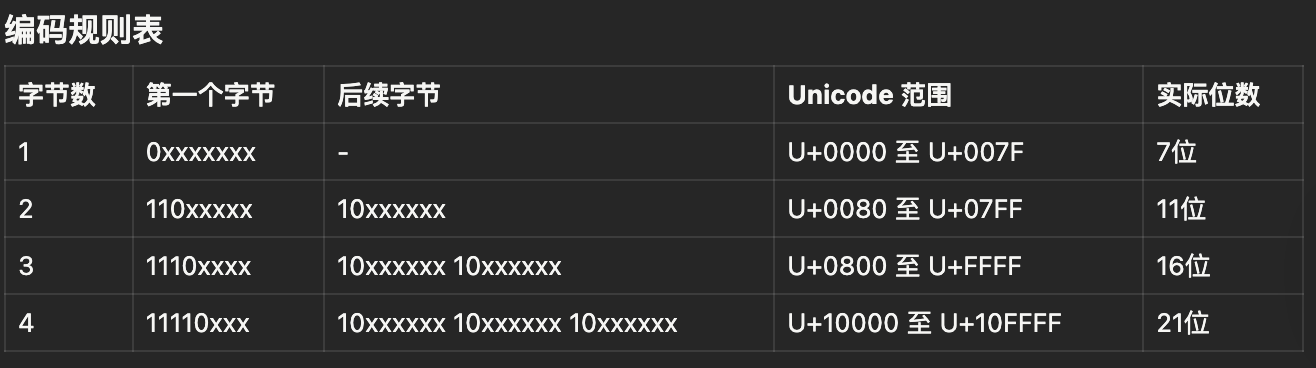

每个符号编码后第一个字节的高端bit位用于表示总共有多少编码个字节，后续的每个高端bit都以10开头。

## word-level tokenizers vs byte-level tokenizers:
- word-level: much larger vocabulary; out of vocabulary
- byte-level: 256-sized vocabulary; no out of vocabulary; but more tokens for the same text

```python

## BPE Tokenizer
### three main steps:
1. Vocabulary initialization: initial vocabulary is simply the set of all
bytes(size 256) 
2. Pre-tokenization: count how often bytes occur next
to each other in your text and begin merging them starting with the most frequent pair of bytes
    - Problem: However,this is quite computationally expensive, since we’d have to go take a full pass over the corpus each time we merge. In addition, directly merging bytes across the corpus may result in tokens that differ only in punctuation (e.g., dog! vs. dog.). These tokens would get completely different token IDs, even though they are likely to have high semantic similarity (since they differ only in punctuation).
    - To avoid this, we pre-tokenize the corpus. You can think of this as a coarse-grained tokenization over the corpus that helps us count how often pairs of characters appear. For example, the word 'text' might be a pre-token that appears 10 times. In this case, when we count how often the characters ‘t’ and ‘e’ appear next to each other, we will see that the word ‘text’ has ‘t’ and ‘e’ adjacent and we can increment their count by 10 instead of looking through the corpus. 
    - regex-based pre-tokenizer (used by GPT-2)
3. Compute BPE merges: the BPE algorithm iteratively counts every pair of bytes and identifies the pair with the highest frequency (“A”, “B”). Every occurrence of this most frequent pair (“A”, “B”) is then merged. For eﬀiciency during BPE training, we do not consider pairs that cross pre-token boundaries. When computing merges, deterministically break ties in pair frequency by preferring the lexicographically greater pair.

### Special tokens 
Often, some strings (e.g., <|endoftext|>) are used to encode metadata (e.g., boundaries between documents). When encoding text, it’s often desirable to treat some strings as “special tokens” that should never be split into multiple tokens (i.e., will always be preserved as a single token).

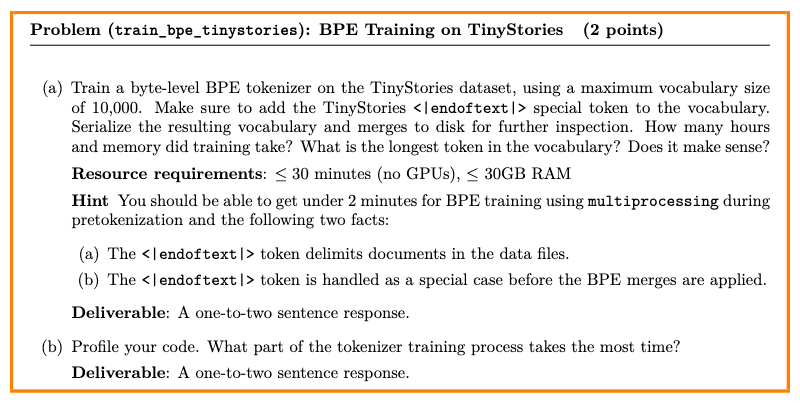

(a) pre-tokenization(15.68s) + build frequency dictionary(0.08s) + initial pair frequency(0.11s) + merging pairs(31.26s) = 47.13s; b' accomplishment' 15.

(b) merging pairs(31.26s)

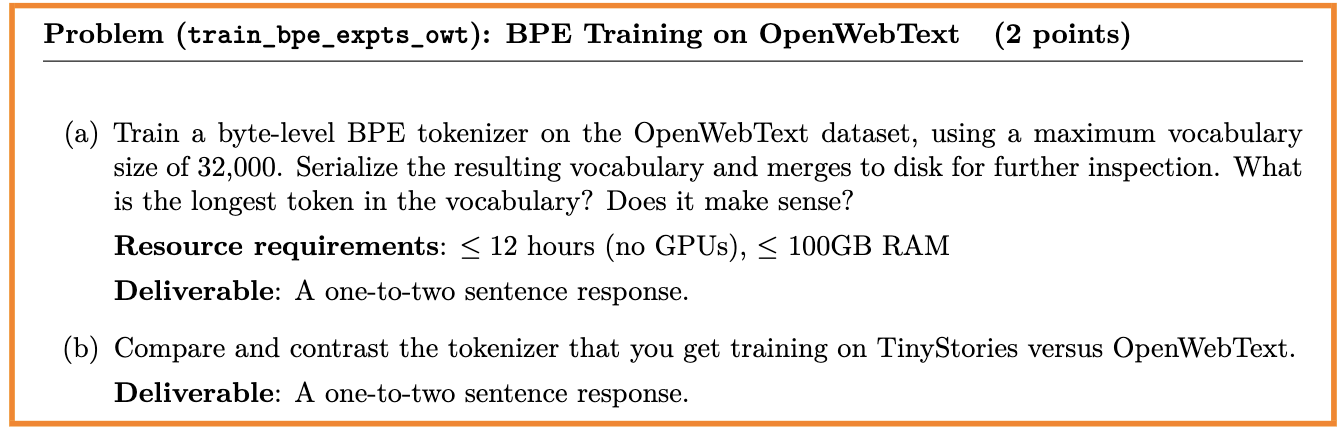

(a) pre-tokenization(89.25s) + build frequency dictionary(25.15) + initial pair frequency(21.44) + merging pairs(19355.15); b'\xc3\x83\xc3\x82\xc3\x83\xc3\x82\xc3\x83\xc3\x82\xc3\x83\xc3\x82\xc3\x83\xc3\x82\xc3\x83\xc3\x82\xc3\x83\xc3\x82\xc3\x83\xc3\x82\xc3\x83\xc3\x82\xc3\x83\xc3\x82\xc3\x83\xc3\x82\xc3\x83\xc3\x82\xc3\x83\xc3\x82\xc3\x83\xc3\x82\xc3\x83\xc3\x82\xc3\x83\xc3\x82' 64

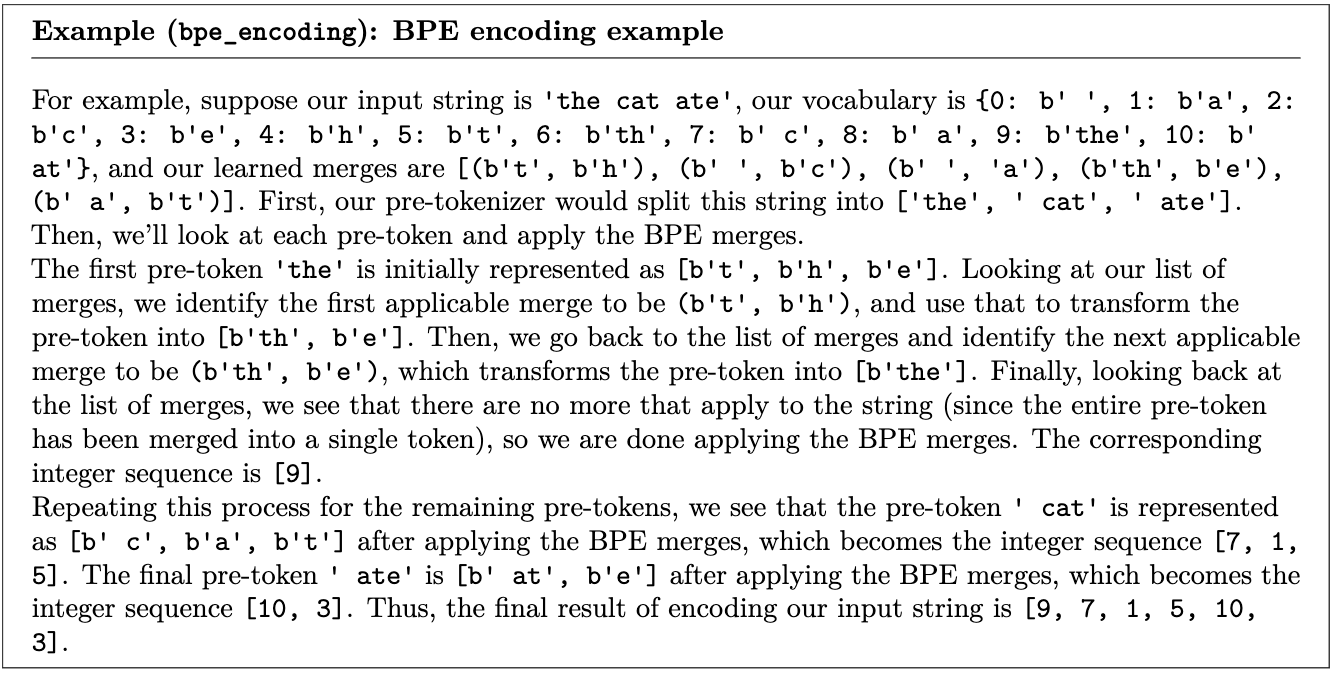

# Transformer Language Model Architecture

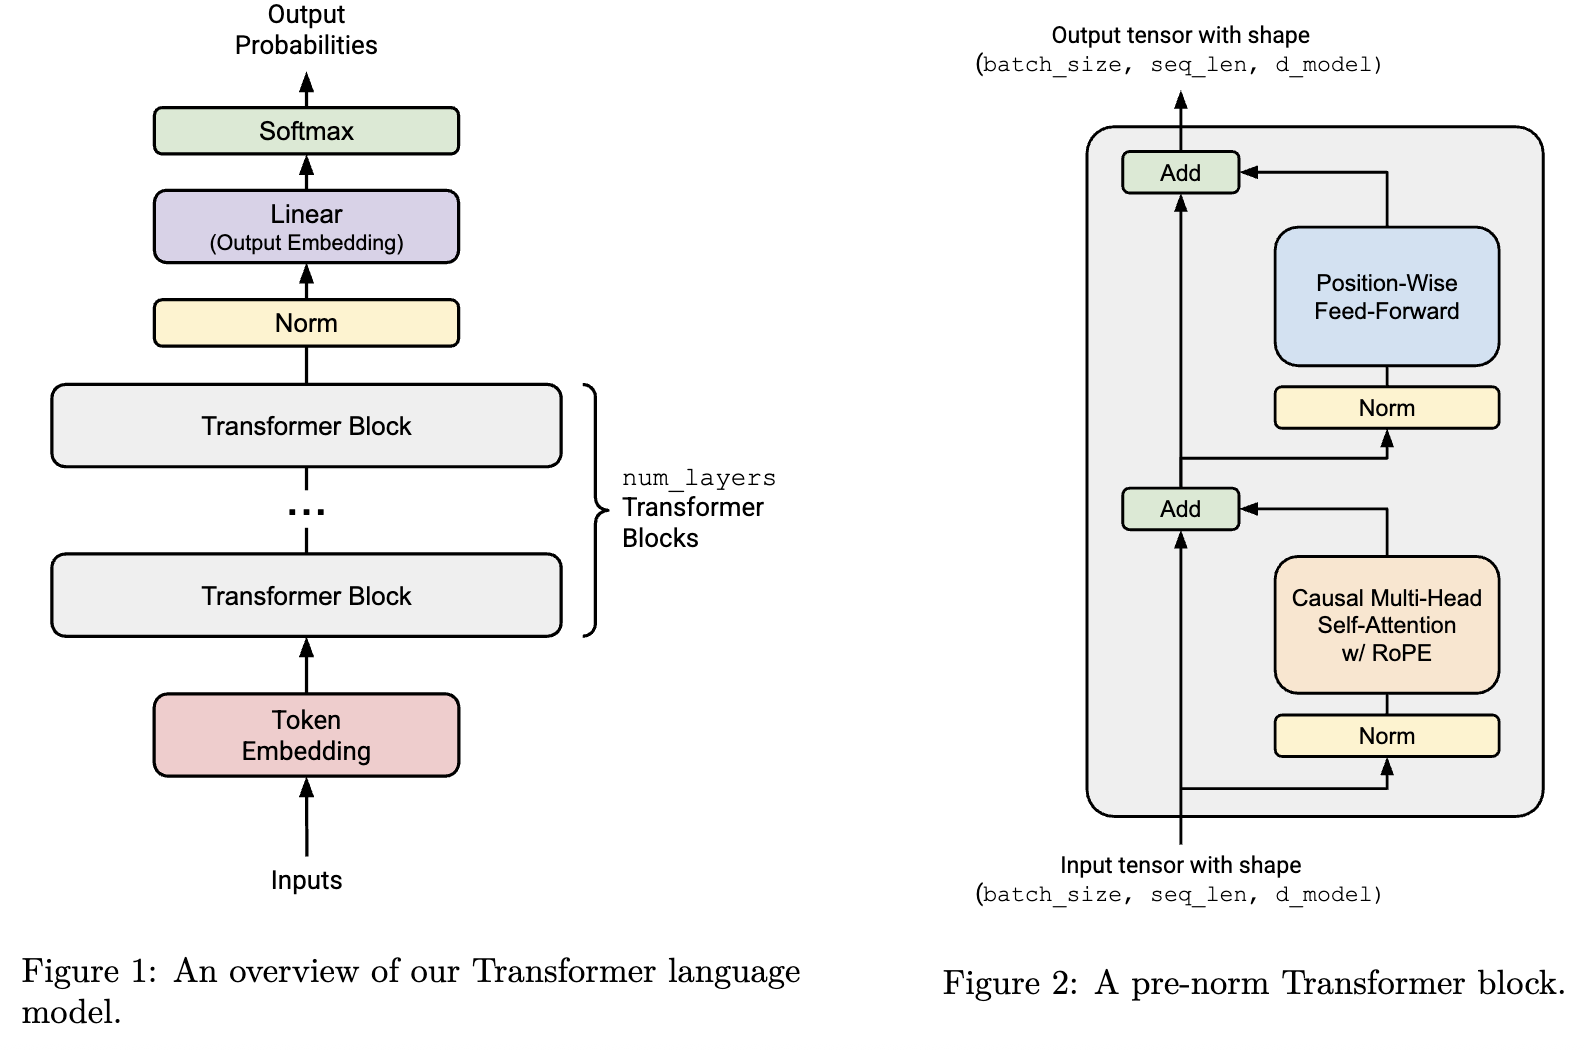

- Token Embeddings

    Each embedding layer takes in a tensor of integers of shape (batch_size, sequence_length) and produces a sequence of vectors of shape (batch_size, sequence_length, d_model)
- Pre-norm Transformer Block

    Each Transformer block takes in an input of shape (batch_size, sequence_length, d_model) and returns an output of shape (batch_size,sequence_length, d_model). Each block aggre-gates information across the sequence (via self-attention) and non-linearly transforms it (via the feed-forward layers)

- Output Normalization and Embedding

    requires the use of layer normalization (detailed below) after the final Transformer block to ensure its outputs are properly scaled. After this normalization, we will use a standard learned linear transformation to convert the output of the Transformer blocks into predicted next-token logits

## Basic Building Blocks: Linear and Embedding Modules
- Parameter Initialization
    
    Training neural networks effectively often requires careful initialization of the model parameters—bad initial-izations can lead to undesirable behavior such as vanishing or exploding gradients
    
    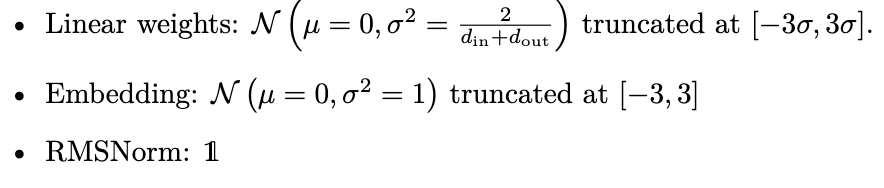

- Linear Module
    
    do not include a bias term, following most modern LLMs

## Pre-Norm Transformer Block
> Each Transformer block has two sub-layers: a **multi-head self-attention mechanism** and a **position-wise feed-forward network**
- post-norm: uses a residual connection around each of the two sub-layers, followed by layer normalization
- pre-norm: moving layer normalization from the output of each sub-layer to the input of each sub-layer (with an additional layer normalization after the final Transformer block)
  - improves Transformer training stability
  - An intuition for pre-norm is that there is a clean “residual stream” without any normalization going from the input embeddings to the final output of the Transformer

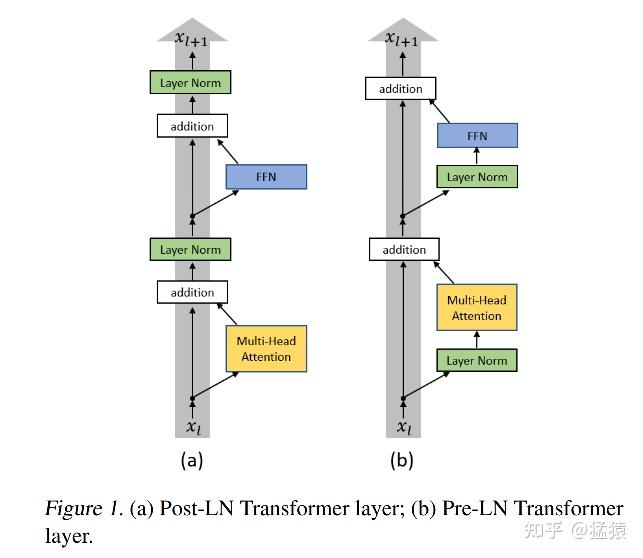

### Root Mean Square Layer Normalization
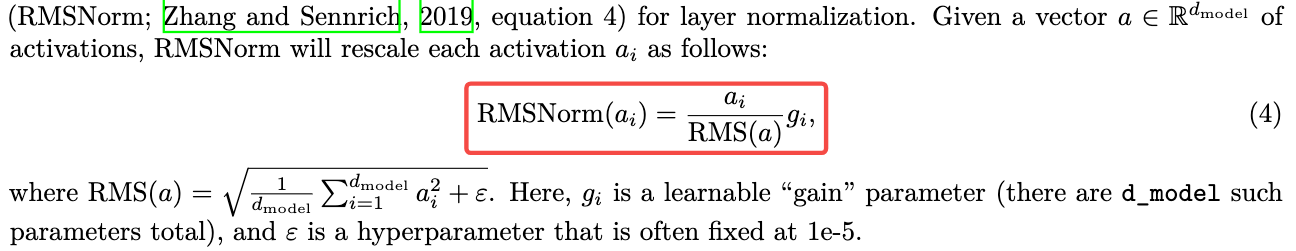

### Position-Wise Feed-Forward Network
- SiLU or Swish activation function: $\text{SiLU}(x) = x \cdot \sigma(x)=x \cdot \cfrac{1}{1 + e^{-x}}$
    - **smooth at zero**
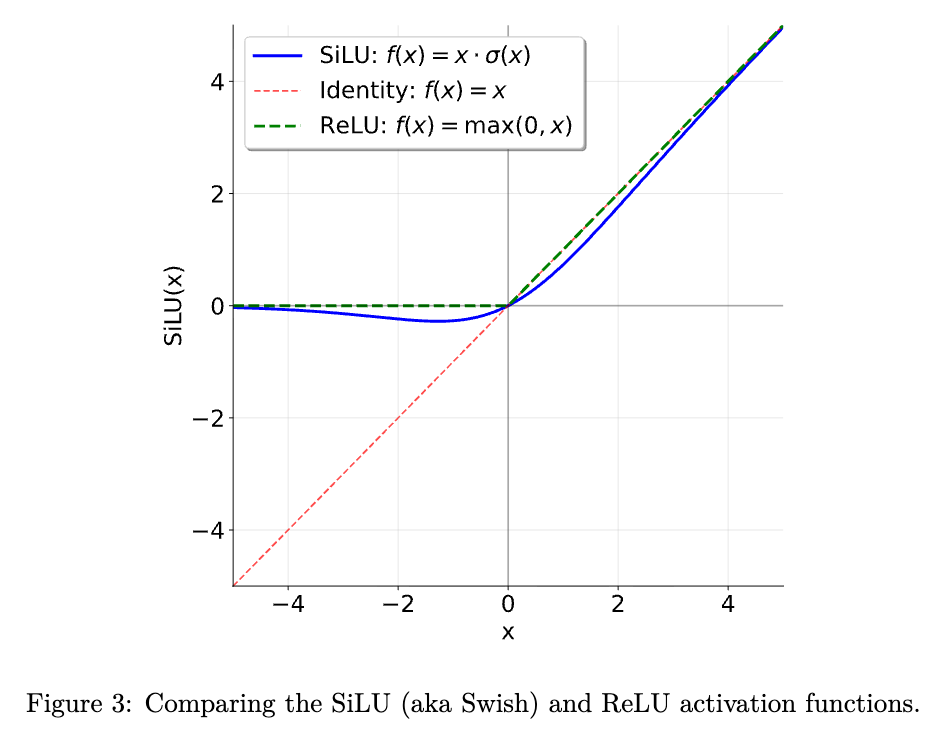

- Gated Linear Units (GLUs): $\text{GLU}(x,W_1,W_2)=\sigma(W_1x) \odot W_2x$
    - $\odot$: element-wise multiplication
    - reduce the vanishing gradient problem

- SwiGLU: $\text{FFN}(x)=\text{SwiGLU}(x,W_1,W_2,W_3)=W_2(\text{SiLU}(W_1x) \odot W_3x)$

    - where $x \in \mathbb{R}^{d_{\text{model}}}$，$W_1, W_3 \in \mathbb{R}^{d_{\text{ff}} \times d_{\text{model}}}$，$W_2 \in \mathbb{R}^{d_{\text{model}} \times d_{\text{ff}}}$，and canonically $d_{\text{ff}} = \frac{8}{3} d_{\text{model}}$。
    - tradtional FFN: 2 linear layer and $d_{\text{ff}}=4 d_{\text{model}}$
    - SwiGLU FNN: 3 linear layer and $d_{\text{ff}}=\frac{8}{3} d_{\text{model}}$
        -  both have the same number of parameters
